In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Part I: Data preparation & analysis

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

base_path = '/content/drive/MyDrive/AAX/seminar 3/dataset/'

rssi = pd.read_csv(base_path + 'rssi_data.csv', header=None)
labels = pd.read_csv(base_path + 'labels_data.csv', header=None)

print("Data loaded correctly!")
print("RSSI shape:", rssi.shape)
print(rssi.head())
print("\nLabels shape:", labels.shape)
print(labels.head())

Data loaded correctly!
RSSI shape: (1500, 3)
        0        1       2
0 -21.949  -99.659 -42.257
1 -34.049  -95.964 -47.779
2 -18.861 -100.000 -34.175
3 -53.497  -77.368 -67.360
4 -54.986  -73.012 -69.780

Labels shape: (1500, 1)
   0
0  5
1  4
2  5
3  2
4  2


2D Plot

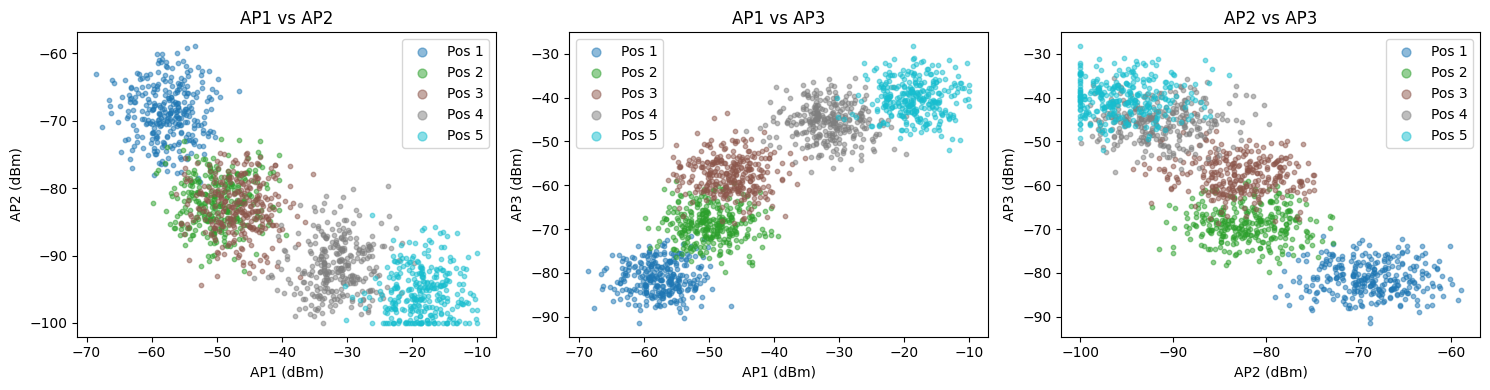

In [9]:
ap1 = rssi.iloc[:, 0].values
ap2 = rssi.iloc[:, 1].values
ap3 = rssi.iloc[:, 2].values
loc = labels.iloc[:, 0].values

pairs = [('AP1', 'AP2', ap1, ap2),
         ('AP1', 'AP3', ap1, ap3),
         ('AP2', 'AP3', ap2, ap3)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 5))

for ax, (xname, yname, x, y) in zip(axes, pairs):
    for i, pos in enumerate(np.unique(loc)):
        mask = loc == pos
        ax.scatter(x[mask], y[mask], label=f'Pos {pos}', color=colors[i], alpha=0.5, s=10)
    ax.set_xlabel(xname + ' (dBm)')
    ax.set_ylabel(yname + ' (dBm)')
    ax.set_title(f'{xname} vs {yname}')
    ax.legend(markerscale=2)

plt.tight_layout()
plt.show()

In the plots above we can see the RSSI perceived by each pair of APs.

**AP1 vs AP2:** Positions 2 and 3 are overlapping, which makes them difficult to separate using only the two APs.

**AP1 vs AP3:** In this plot there is a visible positive correlation, the stronger the signal at AP1, the stronger at AP3 too.

**AP2 vs AP3:** Positions 5 and 4 and 3 and 2 are also overlapping a little, while 1 is well separated but it's weak in AP3.

With this we can conclude that we can't separate well all the five positions in a 2D space.

3D Plots

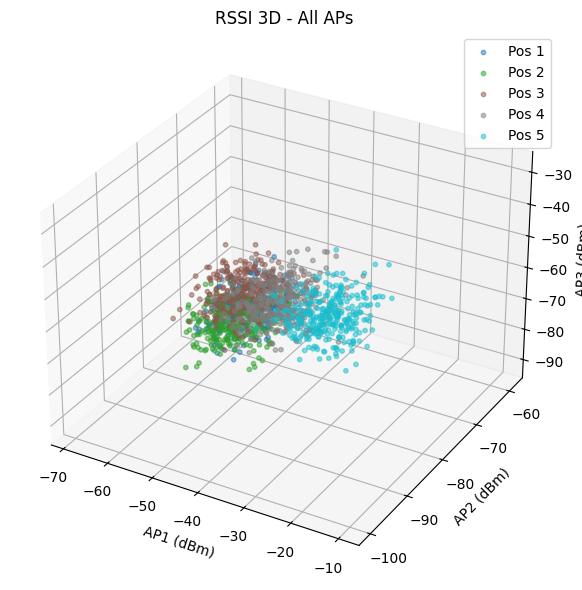

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for i, pos in enumerate(np.unique(loc)):
    mask = loc == pos
    ax.scatter(ap1[mask], ap2[mask], ap3[mask],
               label=f'Pos {pos}', color=colors[i], alpha=0.5, s=10)

ax.set_xlabel('AP1 (dBm)')
ax.set_ylabel('AP2 (dBm)')
ax.set_zlabel('AP3 (dBm)')
ax.set_title('RSSI 3D - All APs')
ax.legend()
plt.tight_layout()
plt.show()

The 3D scatter plot allows us to visualize the spatial distribution of all five positions in the full feature space.
From the plot, we can see that Pos 1 and 5 are more separated from the rest, showing a stronger signal with AP1 than the other access points.
The remaining positions (2–4) form a denser cluster on the left side of the plot, with weaker AP1 readings. Within this group, Pos 3 and Pos 4 overlap significantly, making them harder to distinguish, while Pos 2 show slightly different AP2 values, providing some degree of separability in that dimension.

Statistics

               0                    1                    2          
            mean       std       mean       std       mean       std
label                                                               
1     -57.547793  3.676167 -68.772187  4.041594 -81.156930  3.748209
2     -49.811667  3.892066 -81.979633  3.760133 -68.978473  3.869161
3     -46.740827  3.951756 -82.877667  3.981708 -57.633320  4.141495
4     -31.584760  4.058027 -91.492630  3.944587 -45.475647  4.102736
5     -18.477953  3.860880 -95.344790  3.531129 -40.081403  4.128701


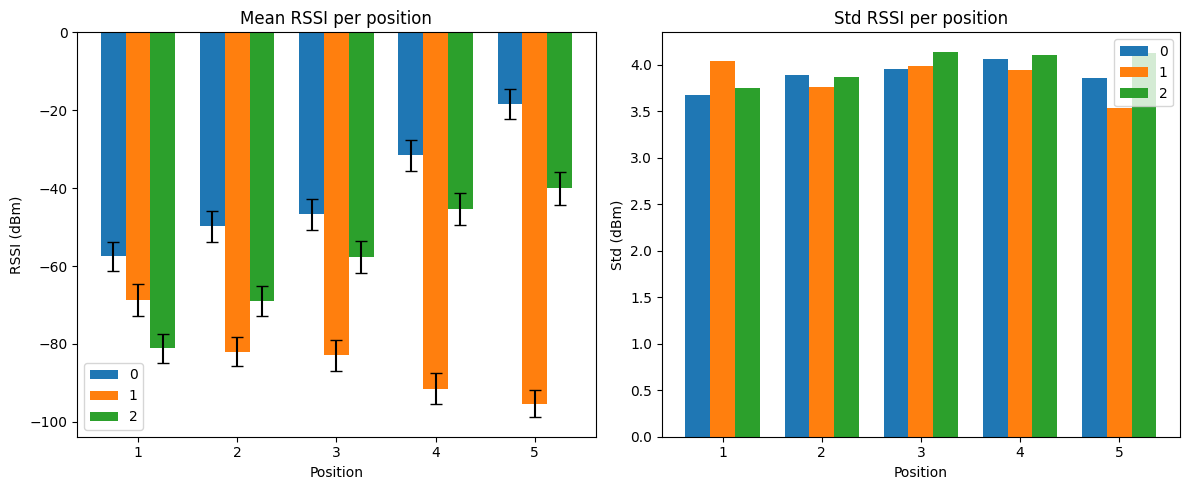

In [11]:
rssi['label'] = loc

stats = rssi.groupby('label').agg(['mean', 'std'])
print(stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ap_names = [rssi.columns[0], rssi.columns[1], rssi.columns[2]]
positions = np.unique(loc)
x = np.arange(len(positions))
width = 0.25

for i, ap in enumerate(ap_names):
    means = [rssi[rssi['label'] == p][ap].mean() for p in positions]
    stds  = [rssi[rssi['label'] == p][ap].std()  for p in positions]
    axes[0].bar(x + i*width, means, width, label=ap, yerr=stds, capsize=4)
    axes[1].bar(x + i*width, stds,  width, label=ap)

axes[0].set_title('Mean RSSI per position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(positions)
axes[0].legend()

axes[1].set_title('Std RSSI per position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Std (dBm)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(positions)
axes[1].legend()

plt.tight_layout()
plt.show()

The tables and bar plots show the mean and standard deviation of RSSI for each AP across the 5 positions.

**Mean RSSI:** We can see a clear trend across positions.
AP1  increases steadily from Pos 1 up to Pos 5, meaning the device gets progressively closer to AP0, while AP2 does the opposite, indicating the device moves further away from it. For the last access point (green) there is also a decreasing trend, but it stabilices slightly at Pos 4 and 5.

**Std RSSI:** The std values are quite consistent across all positions and APs, ranging between 3.5 and 4.1 dBm. This indicates that the measurement noise is homogeneous and any position or AP suffers from higher variability than the others.

# Part 2

In [12]:
def kmeans(X, K, max_iter=100, seed=42):
    #X: array (N, D)
    #K: number of clusters
    #Returns: centroids (K, D), assignments (N,), history de centroides

    rng = np.random.default_rng(seed)

    #Random initialization of centroids (according to the data)
    mins, maxs = X.min(axis=0), X.max(axis=0)
    centroids = rng.uniform(mins, maxs, size=(K, X.shape[1]))

    assignments = np.full(len(X), -1)

    for i in range(max_iter):

        #Step 1: assign each data point to it's nearest centroid
        #Euclidean distance
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)  #(N, K)
        new_assignments = np.argmin(dists, axis=1)  # (N,)

        #Step 2: update
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            mask = new_assignments == k
            if mask.sum() == 0:
                #if the cluster is empty, we restart it randomly
                new_centroids[k] = rng.uniform(mins, maxs)
            else:
                new_centroids[k] = X[mask].mean(axis=0)

        #check convergence
        #the assignment of clusters to each point does not vary
        if np.all(new_assignments == assignments):
            print(f'Converged at iteration {i+1}')
            break

        assignments = new_assignments
        centroids = new_centroids
        #we have reached the max num of iterations
    else:
        print(f'Reached max iterations ({max_iter})')

    return centroids, assignments

In [13]:
K = 5
X = rssi[[0, 1, 2]].values

centroids, pred_clusters = kmeans(X, K=K, max_iter=100)

print("Centroids:\n", centroids)
print("Unique predicted clusters:", np.unique(pred_clusters))

Converged at iteration 8
Centroids:
 [[-31.70011438 -91.51220915 -45.53802941]
 [-18.29872727 -95.34978114 -40.02738384]
 [-57.56871854 -68.81464238 -81.1162649 ]
 [-46.96907869 -82.84256066 -57.59046557]
 [-49.66421034 -81.96361379 -69.35433793]]
Unique predicted clusters: [0 1 2 3 4]


**Convergence:** The algorithm converged in just 8 iterations,  which indicates that the 5 clusters were well-defined and the centroids stabilized quickly.

**Centroids:** The centroids are virtually identical to the real position means, confirming that K-Means successfully recovered the 5 true locations.

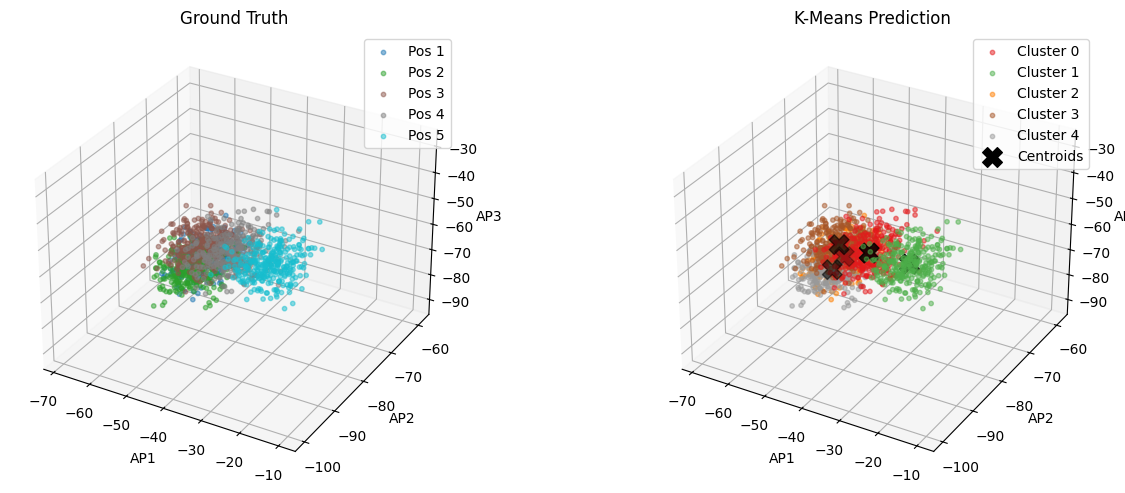

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})

#Ground truth:
for i, pos in enumerate(np.unique(loc)):
    mask = loc == pos
    axes[0].scatter(ap1[mask], ap2[mask], ap3[mask],
                    color=colors[i], label=f'Pos {pos}', alpha=0.5, s=10)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('AP1'); axes[0].set_ylabel('AP2'); axes[0].set_zlabel('AP3')
axes[0].legend()

#K-Means
pred_colors = plt.cm.Set1(np.linspace(0, 1, K))
for k in range(K):
    mask = pred_clusters == k
    axes[1].scatter(ap1[mask], ap2[mask], ap3[mask],
                    color=pred_colors[k], label=f'Cluster {k}', alpha=0.5, s=10)
axes[1].scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                color='black', marker='X', s=200, label='Centroids', zorder=5)
axes[1].set_title('K-Means Prediction')
axes[1].set_xlabel('AP1'); axes[1].set_ylabel('AP2'); axes[1].set_zlabel('AP3')
axes[1].legend()

plt.tight_layout()
plt.show()

Looking at both 3D plots, the cluster shapes in the K-Means prediction almost mirror the ground truth. We can see the same overlap in the prediction as the actual graphic, specially in Pos 3 and 4, which corresponds to cluster 0 and 3. This is consistent with what we observed in Part I.
Overall, the K-Means algorithm performs very well on this dataset, successfully identifying all 5 positions without any labeled data during training.